# Automatic Detection of Sleep Apneas in Children


### In this tutorial, there will be implemented three models to automatically detect apnea events: BiLSTM, ML ensemble and an hybrid approach coupling the previous ones.

In [57]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import os, sys
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from torch.nn.utils.rnn import pad_sequence
from datetime import datetime, timedelta
import random

notebook_dir = os.getcwd()
parent_dir = os.path.join(notebook_dir, '..')
sys.path.append(parent_dir)
from aether.rnn_bilstm import BILSTMModel
from aether.respiratory_dataset import RespiratoryDataset
from aether.utils_rnn import collate_fun, evaluate_model, find_best_threshold, calculate_metrics
from aether.utils_data import  check_apnea_criteria, compare_intervals, merge_time_intervals, check_stringa


ImportError: cannot import name 'check_stringa' from 'aether.utils_data' (/scratch/lmeneghe/AETHER/tutorials/../aether/utils_data.py)

### Load data and extract only the relevant features from the data features. To understand which features are relevant see the feat_selection tutorial.

In [4]:
#Execute this when you have your files with the correct data
with open('../resp_events.pkl', 'rb') as f:
    resp_events = pickle.load(f)


print('N. resp events', len(resp_events))
resp_labels=np.load("../resp_labels.npy") 
print('N. resp labels', len(resp_labels))
resp_feat=np.load("../resp_feat.npy") 
print('N. features', len(resp_feat[0]))

# extract only feautures 0,3,7,9 (important one) 
df = pd.DataFrame(resp_feat)
idx_sel = [0, 3, 7, 9]
resp_feat_sel = df.iloc[:, idx_sel]
resp_feat  = resp_feat_sel.to_numpy()
print('N. features', len(resp_feat[0]))


N. resp events 121464
N. resp labels 121464
N. features 10
N. features 4


In [3]:
# Generate dummy data to perform simulation
n_events = 10000 
n_features = 10 

# unbalanced ratio (80% normal events (0), 20% apnea events (1))
non_apnea_ratio = 0.8
n_nonapnea = int(n_events * non_apnea_ratio)
n_apnea = n_events - n_nonapnea

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea} (80%)")
print(f"Apnea Events (Class 1): {n_apnea} (20%)")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)
resp_labels = np.concatenate([labels_non_apnea, labels_apnea])

np.random.shuffle(resp_labels)


# Generate random features for all events using a normal distribution
# to simulate real data
resp_feat = np.random.randn(n_events, n_features).astype(np.float32)

idx_sel = [0, 3, 7, 9]
resp_feat = resp_feat[:, idx_sel]
print('N. features', len(resp_feat[0]))

# Generate random respiratory events value with different length 
resp_events = []
# define an interval for the lenghts of this respiratory events
min_len = 22 
max_len = 35 

for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less nopise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    resp_events.append(signal.astype(np.float32))


Generation of 10000 events
Non apnea Events (Class 0): 8000 (80%)
Apnea Events (Class 1): 2000 (20%)
N. features 4


## Splitting of the dataset into training, validation and testing

In [5]:
resp_combined = list(zip(resp_events, resp_feat))

X = resp_combined
y = resp_labels

original_idx_seq = np.arange(len(X))
X_train_val, X_test, y_train_val, y_test, train_idx, test_idx = train_test_split(
    X, y, original_idx_seq, test_size=0.2, random_state=42) #, stratify=y
#)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42) #, stratify=y_train_val
#)

print(f"\nTraining set shape: {len(X_train)}")
print(f"Validation set shape: {len(X_val)}")
print(f"Test set shape: {len(X_test)}\n")


Training set shape: 72878
Validation set shape: 24293
Test set shape: 24293



# BiLSTM
### Load the model and prepare the data for its training, validation and testing phases.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilstm_model = BILSTMModel(input_size=1).to(device)

print("\n" + "="*70)
print("BiLSTM MODEL")
print("="*70)
# Create train, validation and test datasets

#compute class weights (inverse of frequency)
class_counts = np.bincount(y_train)  #coutn occurences of each class
class_weights = 1./ class_counts
weights = class_weights[y_train]  #assign weight to each sample

train_seq = [x[0] for x in X_train]
test_seq = [x[0] for x in X_test]
val_seq = [x[0] for x in X_val]

#create a sampler using these weights (imbalances dataset)
sampler = WeightedRandomSampler(weights, num_samples=len(y_train), replacement=True)

# Create Dataset objects
train_dataset = RespiratoryDataset(train_seq, y_train, augment=False)
test_dataset = RespiratoryDataset(test_seq, y_test, augment=False)
val_dataset = RespiratoryDataset(val_seq, y_val, augment=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, collate_fn=collate_fun, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, collate_fn=collate_fun)
val_loader = DataLoader(val_dataset, batch_size=512, collate_fn=collate_fun)

# Calculate weights for BCELoss
class_0_count = class_counts[0]
class_1_count = class_counts[1]
# The weight for the minority class is the ratio of the majority class to the minority class
pos_weight = torch.tensor([class_0_count / class_1_count]).to(device)


BiLSTM MODEL


In [7]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(bilstm_model.parameters(), lr=0.0001, weight_decay=1e-4)

### Training phase

In [8]:
num_epochs = 50
for epoch in range(num_epochs):
    bilstm_model.train()
    total_loss = 0

    for X_batch, y_batch, seq_len_batch, sorted_idx in train_loader:
        X_batch, y_batch, seq_len_batch = X_batch.to(device), y_batch.to(device), seq_len_batch #.to(device)
        optimizer.zero_grad()
        X_batch = X_batch.unsqueeze(-1)
        outputs = bilstm_model(X_batch, seq_len_batch)

        loss = criterion(outputs.squeeze().to(device), y_batch.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()/float(seq_len_batch.size(0))

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Learning rate: {current_lr}")

torch.save(bilstm_model.state_dict(), "bilstm_50ep.pth")

Epoch 1/50, Loss: 18.8586, Learning rate: 0.0001
Epoch 2/50, Loss: 10.5953, Learning rate: 0.0001
Epoch 3/50, Loss: 8.9943, Learning rate: 0.0001
Epoch 4/50, Loss: 7.0592, Learning rate: 0.0001
Epoch 5/50, Loss: 6.6846, Learning rate: 0.0001
Epoch 6/50, Loss: 6.0349, Learning rate: 0.0001
Epoch 7/50, Loss: 5.8119, Learning rate: 0.0001
Epoch 8/50, Loss: 5.4269, Learning rate: 0.0001
Epoch 9/50, Loss: 5.3506, Learning rate: 0.0001
Epoch 10/50, Loss: 5.0901, Learning rate: 0.0001
Epoch 11/50, Loss: 5.0230, Learning rate: 0.0001
Epoch 12/50, Loss: 4.7608, Learning rate: 0.0001
Epoch 13/50, Loss: 4.5894, Learning rate: 0.0001
Epoch 14/50, Loss: 4.5353, Learning rate: 0.0001
Epoch 15/50, Loss: 4.3499, Learning rate: 0.0001
Epoch 16/50, Loss: 4.2386, Learning rate: 0.0001
Epoch 17/50, Loss: 4.4543, Learning rate: 0.0001
Epoch 18/50, Loss: 4.3218, Learning rate: 0.0001
Epoch 19/50, Loss: 4.0879, Learning rate: 0.0001
Epoch 20/50, Loss: 4.0099, Learning rate: 0.0001
Epoch 21/50, Loss: 4.0774, 

In [9]:
#loading the model from the previous checkpoint
state_dict = torch.load("bilstm_50ep.pth", weights_only=True)
bilstm_model.load_state_dict(state_dict)

<All keys matched successfully>

### Results Training
Evaluate the model to gain its accuracy, the predicted values, the related class probabilities and ordered labels.
N.B. The ordering of the labels is useful when you need to compare the output of this model with that of other models, such as the ML ones.

In [10]:
train_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, train_loader, device)
print(f"Train Accuracy: {train_accuracy:.2f}")

Train Accuracy: 0.88


Refine predictions based on a threshold.

In [11]:
lstm_probs = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs >= best_thresh).astype(int)

Best threshold based on F1-score: 0.9874
Optimal threshold: 0.9874


Calculate all the key metrics to understand the model performance.


REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.98      0.91      0.94     36556
       Apnea       0.91      0.98      0.95     36322

    accuracy                           0.94     72878
   macro avg       0.95      0.94      0.94     72878
weighted avg       0.95      0.94      0.94     72878


--- Confusion Matrix ---
[[33115  3441]
 [  700 35622]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9059
Negative Predictive Value (NPV): 0.9793
Sensitivity (Recall/TPR): 0.9807
Precision (PPV): 0.9119
Accuracy: 0.9432
F1 Score: 0.9451

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9816
Precision-Recall AUC Score: 0.9748


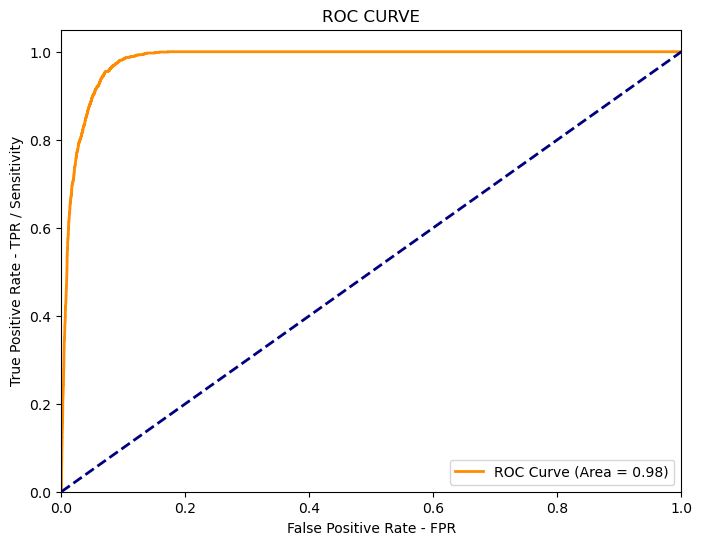

In [12]:
metrics_dict = calculate_metrics(y_true, y_pred, y_probs)

### Results Validation

Validation Accuracy: 0.75
Best threshold based on F1-score: 0.9993
Optimal threshold: 0.9993

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.99      0.99      0.99     23826
       Apnea       0.49      0.65      0.56       467

    accuracy                           0.98     24293
   macro avg       0.74      0.82      0.78     24293
weighted avg       0.98      0.98      0.98     24293


--- Confusion Matrix ---
[[23513   313]
 [  163   304]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9869
Negative Predictive Value (NPV): 0.9931
Sensitivity (Recall/TPR): 0.6510
Precision (PPV): 0.4927
Accuracy: 0.9804
F1 Score: 0.5609

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9643
Precision-Recall AUC Score: 0.4939


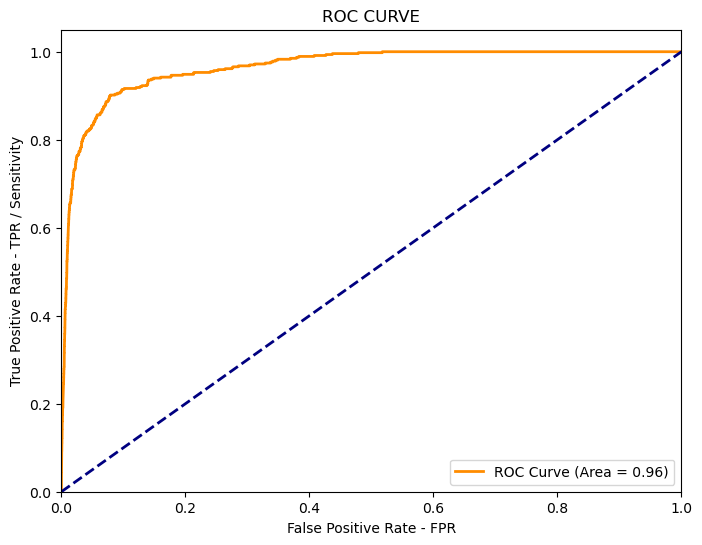

In [13]:
val_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, val_loader, device)
print(f"Validation Accuracy: {val_accuracy:.2f}")

lstm_probs_val = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs_val, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs_val >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs_val)


### Results Testing

Testing Accuracy: 0.75
Best threshold based on F1-score: 0.9994
Optimal threshold: 0.9994

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.99      0.99      0.99     23761
       Apnea       0.55      0.62      0.58       532

    accuracy                           0.98     24293
   macro avg       0.77      0.81      0.79     24293
weighted avg       0.98      0.98      0.98     24293


--- Confusion Matrix ---
[[23485   276]
 [  200   332]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9884
Negative Predictive Value (NPV): 0.9916
Sensitivity (Recall/TPR): 0.6241
Precision (PPV): 0.5461
Accuracy: 0.9804
F1 Score: 0.5825

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9683
Precision-Recall AUC Score: 0.5297


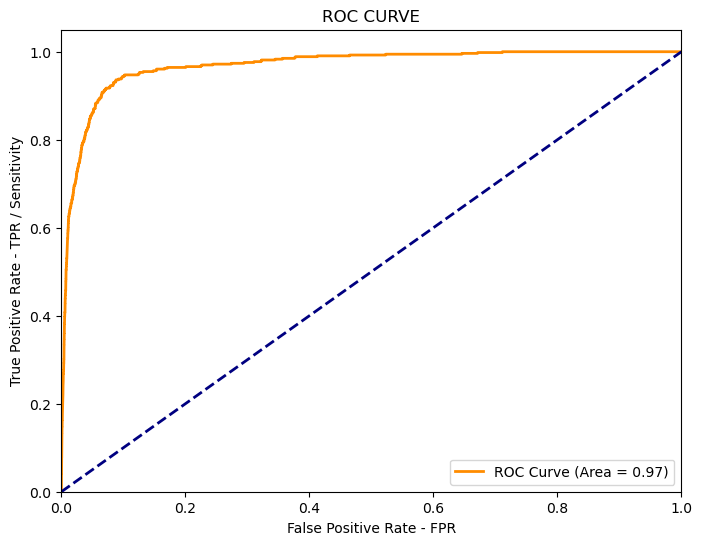

In [14]:
test_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, test_loader, device)
print(f"Testing Accuracy: {test_accuracy:.2f}")

lstm_probs = np.array(y_probs)

best_thresh = find_best_threshold(np.array(y_true), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (lstm_probs >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs)


# ML Ensemble
### Load the model and prepare the data for its training, validation and testing phases.

In [15]:
print("\n" + "="*70)
print("ML ENSEMBLE")
print("="*70)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
pos_weight = sum(y_train == 0) / sum(y_train == 1)

#Train Random Forest, XGBoost, and Logistic Regression
rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=200, random_state=42, oob_score=True, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=20)
xgb = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01, scale_pos_weight=pos_weight, subsample=0.6, gamma=0.3, colsample_bytree=0.8)
lgr = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', C=np.float64(0.00407559644007287))
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

X_train_ml = [x[1] for x in X_train]
X_val_ml = [x[1] for x in X_val]
X_test_ml = [x[1] for x in X_test]


ML ENSEMBLE


### Training phase
Training of the models and successive computation of the several metrics for evaluation.

In [16]:
rf.fit(X_train_ml, y_train)
xgb.fit(X_train_ml, y_train)
lgr.fit(X_train_ml, y_train)
lda.fit(X_train_ml, y_train)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

### Results validation

In [17]:
rf_probs_val = rf.predict_proba(X_val_ml)[:, 1]
xgb_probs_val = xgb.predict_proba(X_val_ml)[:, 1]
lgr_probs_val = lgr.predict_proba(X_val_ml)[:, 1]
lda_probs_val = lda.predict_proba(X_val_ml)[:, 1]

clf = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('lgr', lgr), ('lda', lda)], voting='soft')
clf.fit(X_train_ml, y_train)
final_predictions=clf.predict(X_val_ml)
ml_probs = clf.predict_proba(X_val_ml)[:,1]

In [18]:
best_thresh = find_best_threshold(y_val, ml_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (np.array(ml_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.4785
Optimal threshold: 0.4785



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.99      0.99      0.99     23826
       Apnea       0.54      0.57      0.55       467

    accuracy                           0.98     24293
   macro avg       0.76      0.78      0.77     24293
weighted avg       0.98      0.98      0.98     24293


--- Confusion Matrix ---
[[23598   228]
 [  203   264]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9904
Negative Predictive Value (NPV): 0.9915
Sensitivity (Recall/TPR): 0.5653
Precision (PPV): 0.5366
Accuracy: 0.9823
F1 Score: 0.5506

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9373
Precision-Recall AUC Score: 0.5434


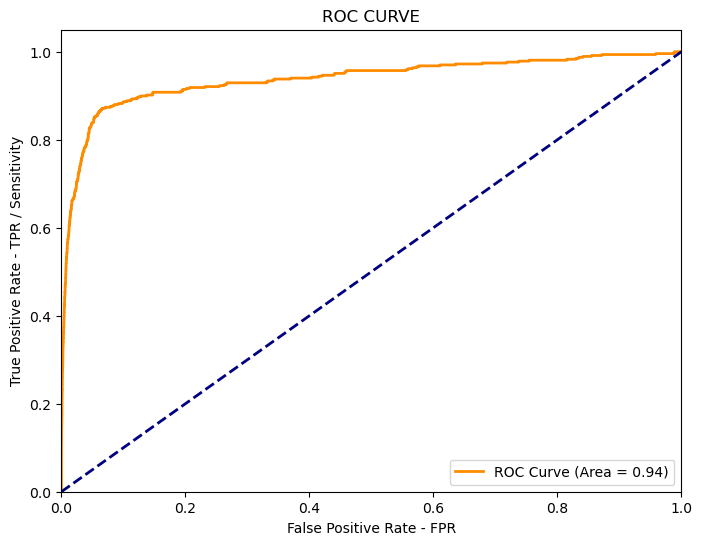

In [19]:
metrics_dict = calculate_metrics(y_val, y_pred, ml_probs)

### Results Testing

In [20]:
rf_probs = rf.predict_proba(X_test_ml)[:, 1]
xgb_probs = xgb.predict_proba(X_test_ml)[:, 1]
lgr_probs = lgr.predict_proba(X_test_ml)[:, 1]
lda_probs = lda.predict_proba(X_test_ml)[:, 1]

final_predictions=clf.predict(X_test_ml)
ml_probs = clf.predict_proba(X_test_ml)[:,1]
best_thresh = find_best_threshold(y_val, ml_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_pred = (np.array(ml_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.1363
Optimal threshold: 0.1363



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.55      0.71     23761
       Apnea       0.04      0.94      0.09       532

    accuracy                           0.56     24293
   macro avg       0.52      0.74      0.40     24293
weighted avg       0.98      0.56      0.69     24293


--- Confusion Matrix ---
[[13018 10743]
 [   31   501]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.5479
Negative Predictive Value (NPV): 0.9976
Sensitivity (Recall/TPR): 0.9417
Precision (PPV): 0.0446
Accuracy: 0.5565
F1 Score: 0.0851

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9298
Precision-Recall AUC Score: 0.5677


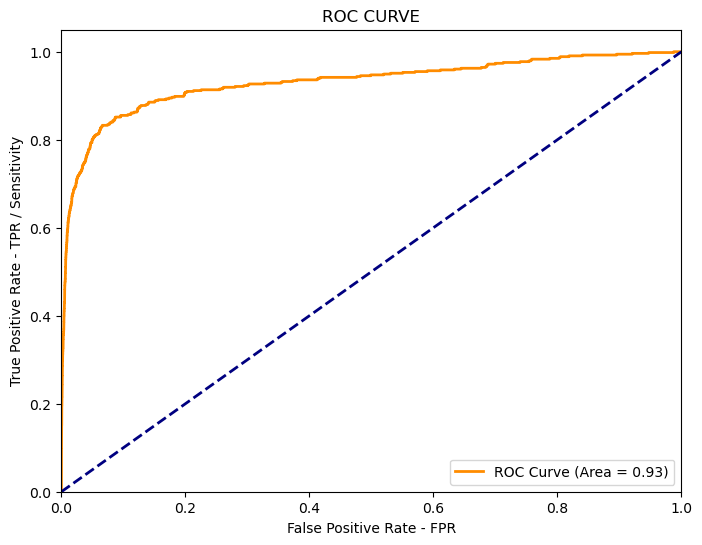

In [21]:
metrics_dict = calculate_metrics(y_test, y_pred, ml_probs)

# Hybrid model
Combine predictions of the three models to get a better prediction using information from all the models. We are combining them computing their average with equal weights.

### Results Validation

In [22]:
print("\n" + "="*70)
print("HYBRID APPROACH")
print("="*70)

bilstm_model.eval()
# Combine models testing predictions to create the meta-features.
meta_features = np.column_stack((rf_probs_val, xgb_probs_val, lgr_probs_val, lda_probs_val, lstm_probs_val))
print(f"Meta-features shape: {meta_features.shape}")


HYBRID APPROACH
Meta-features shape: (24293, 5)


In [23]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # equal weights

# final probabilities computed as weighted average
final_weighted_probs = np.average(meta_features, axis=1, weights=weights)

best_thresh = find_best_threshold(y_val, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_pred = (np.array(final_weighted_probs) >= best_thresh).astype(int)

Best threshold based on F1-score: 0.5825
Optimal threshold: 0.5825



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.99      0.99      0.99     23826
       Apnea       0.54      0.56      0.55       467

    accuracy                           0.98     24293
   macro avg       0.76      0.78      0.77     24293
weighted avg       0.98      0.98      0.98     24293


--- Confusion Matrix ---
[[23599   227]
 [  205   262]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9905
Negative Predictive Value (NPV): 0.9914
Sensitivity (Recall/TPR): 0.5610
Precision (PPV): 0.5358
Accuracy: 0.9822
F1 Score: 0.5481

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9614
Precision-Recall AUC Score: 0.5506


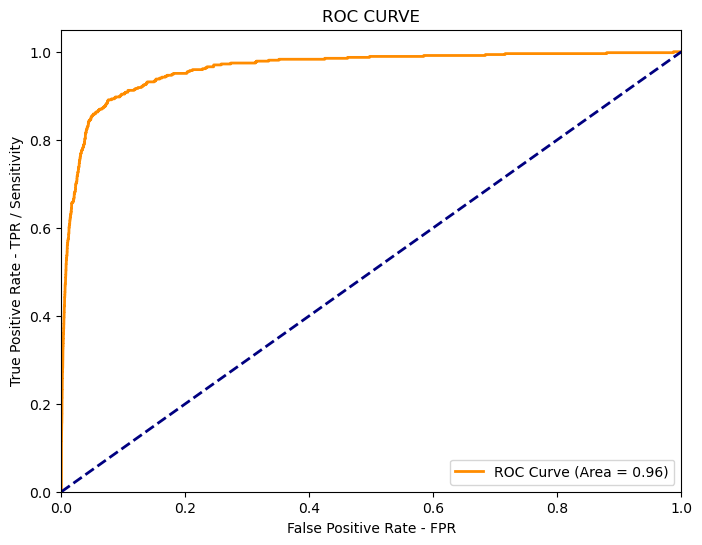

In [24]:
metrics_dict = calculate_metrics(y_val, y_pred, final_weighted_probs)

### Results Testing

In [25]:

# Combine models testing predictions to create the meta-features.
meta_features = np.column_stack((rf_probs, xgb_probs, lgr_probs, lda_probs, lstm_probs))
print(f"Meta-features shape: {meta_features.shape}")

Meta-features shape: (24293, 5)


In [26]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # equal weights

# final probabilities computed as weighted average
final_weighted_probs = np.average(meta_features, axis=1, weights=weights)

best_thresh = find_best_threshold(y_test, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_pred = (np.array(final_weighted_probs) >= best_thresh).astype(int)


Best threshold based on F1-score: 0.5651
Optimal threshold: 0.5651



REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.99      0.99      0.99     23761
       Apnea       0.57      0.61      0.59       532

    accuracy                           0.98     24293
   macro avg       0.78      0.80      0.79     24293
weighted avg       0.98      0.98      0.98     24293


--- Confusion Matrix ---
[[23513   248]
 [  206   326]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9896
Negative Predictive Value (NPV): 0.9913
Sensitivity (Recall/TPR): 0.6128
Precision (PPV): 0.5679
Accuracy: 0.9813
F1 Score: 0.5895

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9625
Precision-Recall AUC Score: 0.5806


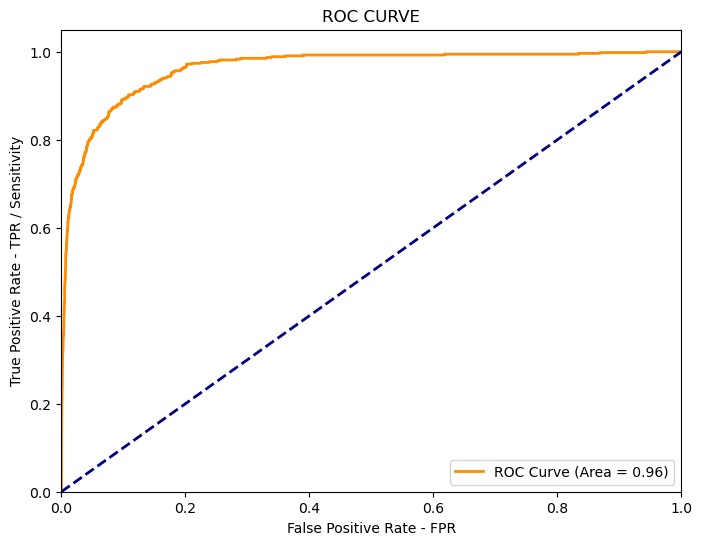

In [27]:
metrics_dict = calculate_metrics(y_test, y_pred, final_weighted_probs)

## Practical Application
Evaluation of the models on a new unseen file. After testing of the model with the new data, we have also introduced an apnea criteria based on medical knowledge on the topic to increase the accuracy of the detection.

In [31]:
# execute this cell uploading your file name
y_eval=np.load("../labels_test.npy")
with open('../data_test.pkl', 'rb') as f:
    X_eval = pickle.load(f)
print('N. test events', len(X_eval))

with open('../time_data_eval.pkl', 'rb') as f:
    time_data = pickle.load(f)

with open('../resp_int_eval.pkl', 'rb') as f:
    resp_int = pickle.load(f)

resp_feat_eval=np.load("../data_test_feat.npy") 
print('N. features', len(resp_feat_eval[0]))

df = pd.DataFrame(resp_feat_eval) #, columns=feature_names)
idx_sel = [0, 2, 7, 9]
resp_feat_sel = df.iloc[:, idx_sel]
resp_feat_eval  = resp_feat_sel.to_numpy()
print('N. features', len(resp_feat_eval[0]))

with open('../apnee_true_eval.pkl', 'rb') as f:
    apnee_true = pickle.load(f)
print('N. apnee', len(apnee_true))


N. test events 1612
N. features 10
N. features 4
N. apnee 53


In [30]:
# Generate dummy data to perform simulation

n_apnea = 10         # apnea events (Label = 1)
n_nonapnea = 40     
n_events = n_apnea + n_nonapnea
n_features = 10      
min_len = 22         
max_len = 35        

# param for non-consecutive gaps
min_gap = 10
max_gap = 100

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea}")
print(f"Apnea Events (Class 1): {n_apnea}")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)

y_eval = np.concatenate([labels_non_apnea, labels_apnea])
np.random.shuffle(y_eval)

print(f"N. Events: {n_events}")

# Generate random features for all events using a normal distribution
# to simulate real data

resp_feat_eval = np.random.randn(n_events, n_features).astype(np.float32)

# feature selection
idx_sel = [0, 3, 7, 9]
resp_feat_eval = resp_feat_eval[:, idx_sel]

print(f'\nN. features: {len(resp_feat_eval[0])}')


# Generate random respiratory events value with different length 

X_eval = []
for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less noise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    X_eval.append(signal.astype(np.float32))


# generation of intervals of the true apneas

resp_int = []
apnee_true_events = []
current_global_index = 0
apnea_intervals_count = 0
t_format = '%H:%M:%S.%f'

for i in range(n_events):
    length = len(X_eval[i])
    label = resp_labels[i]

    start = current_global_index
    end = current_global_index + length - 1

    resp_int.append([start, end])
    # add interval only if it is labeled as 1
    if label == 1:
        apnee_true_events.append([start, end])
        apnea_intervals_count += 1
    
    current_global_index = end + 1
    
    # add the gap (to have non consecutive intervals)
    if i < n_events - 1:
        gap = random.randint(min_gap, max_gap)
        current_global_index += gap

        
total_samples = current_global_index
print(f"Total sequential samples derived: {total_samples}")
print(f"Total respiration intervals: {len(resp_int)}")

# generate the related timestamps for all the sample data

sampling_rate= 1
start_time = datetime.now()
time_data = [(start_time + timedelta(seconds=i / sampling_rate)).strftime(t_format)[:-3] for i in range(total_samples+1000)]

duration_minutes = total_samples / sampling_rate / 60
print(f"Total time duration simulated: {duration_minutes:.2f} minutes")

apnee_true = []

for start_index, end_index in apnee_true_events:

    start_time_apnea = time_data[start_index]
    end_time_apnea = time_data[end_index]
    
    apnee_true.append([start_time_apnea, end_time_apnea])

print(f"N. True apneas: {len(apnee_true)}")


Generation of 50 events
Non apnea Events (Class 0): 40
Apnea Events (Class 1): 10
N. Events: 50

N. features: 4
Total sequential samples derived: 4356
Total respiration intervals: 50
Total time duration simulated: 72.60 minutes
N. True apneas: 13


It can happen that merging files containing the ground-truth apneas some of them are repeated, so this check is added to avoid this.

In [32]:
if len(apnee_true)!=0:
    merged_intervals = merge_time_intervals(apnee_true)
    print('N. apnee', len(merged_intervals))
else:
    merged_intervals = apnee_true
    print('N. apnee', len(apnee_true))


N. apnee 53


### BiLSTM

Prepare data for BiLSTM. Need to keep into account that event sequences have different lenghts, and this must be handled before giving them into input to the BiLSTM network.

In [58]:
eval_seq = [np.array(interval) for interval in X_eval]
# Convert sequences to PyTorch tensors
eval_seq = [torch.tensor(seq, dtype=torch.float32) for seq in eval_seq]

# Get sequence lengths
seq_lengths = torch.tensor([len(seq) for seq in eval_seq])

# Pad sequences to match the longest one
padded_sequences = pad_sequence(eval_seq, batch_first=True)

# Sort sequences by descending length
seq_lengths, sorted_idx = seq_lengths.sort(descending=True)
padded_sequences = padded_sequences[sorted_idx]

seq_lengths_sorted = seq_lengths
tensor_labels = torch.tensor(y_eval, dtype=torch.long)

labels_sorted = tensor_labels[sorted_idx]

In [59]:
lstm_probs = []
y_preds = []
with torch.no_grad():  # Disable gradient computation
    padded_sequences = padded_sequences.to(device)
    padded_events = padded_sequences.unsqueeze(-1)
    print('N. test events', padded_events.size())
    # Forward pass through model
    predictions = bilstm_model(padded_events, seq_lengths_sorted)
    lstm_probs.extend(torch.sigmoid(predictions).cpu().numpy())
    preds = (torch.sigmoid(predictions).cpu().numpy() > 0.5)
    y_preds.extend(preds)


lstm_probs_np = np.concatenate(lstm_probs, axis=0)

# restore orginal order
original_idx = torch.argsort(sorted_idx).numpy()
lstm_probs = lstm_probs_np[original_idx]


N. test events torch.Size([1612, 191, 1])


Best threshold based on F1-score: 0.9989
Optimal threshold: 0.9989

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.98      0.91      0.95      1468
       Apnea       0.49      0.85      0.62       144

    accuracy                           0.91      1612
   macro avg       0.73      0.88      0.78      1612
weighted avg       0.94      0.91      0.92      1612


--- Confusion Matrix ---
[[1339  129]
 [  22  122]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9121
Negative Predictive Value (NPV): 0.9838
Sensitivity (Recall/TPR): 0.8472
Precision (PPV): 0.4861
Accuracy: 0.9063
F1 Score: 0.6177

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9297
Precision-Recall AUC Score: 0.4675


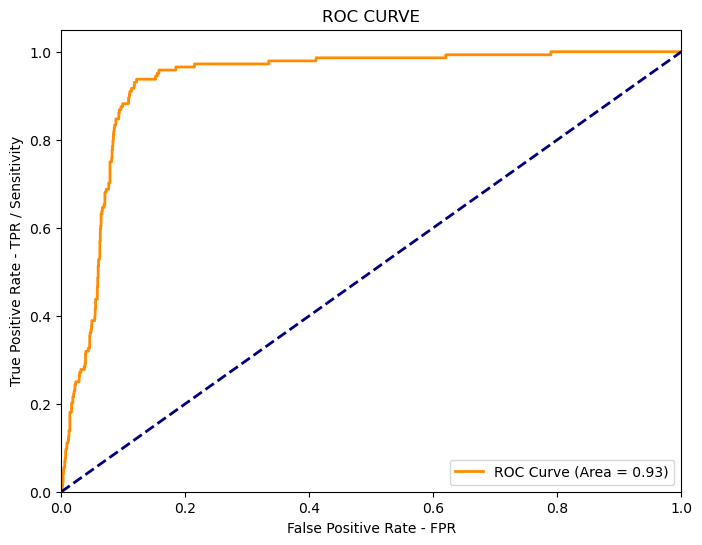

In [60]:

best_thresh = find_best_threshold(np.array(y_eval), lstm_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")

# Apply threshold to new predictions
y_preds = (lstm_probs >= best_thresh).astype(int)

metrics_dict = calculate_metrics(y_eval, y_preds, lstm_probs)


Apnea detected from segment 13 to 14, total duration: 70 seconds
Apnea detected from segment 22 to 23, total duration: 70 seconds
Apnea detected from segment 63 to 66, total duration: 163 seconds
Apnea detected from segment 68 to 71, total duration: 194 seconds
Apnea detected from segment 76 to 77, total duration: 74 seconds
Apnea detected from segment 109 to 111, total duration: 107 seconds
Apnea detected from segment 177 to 181, total duration: 210 seconds
Apnea detected from segment 265 to 266, total duration: 75 seconds
Apnea detected from segment 278 to 279, total duration: 69 seconds
Apnea detected from segment 303 to 305, total duration: 111 seconds
Apnea detected from segment 332 to 333, total duration: 75 seconds
Apnea detected from segment 341 to 342, total duration: 102 seconds
Apnea detected from segment 361 to 362, total duration: 68 seconds
Apnea detected from segment 375 to 378, total duration: 135 seconds
Apnea detected from segment 453 to 454, total duration: 83 second

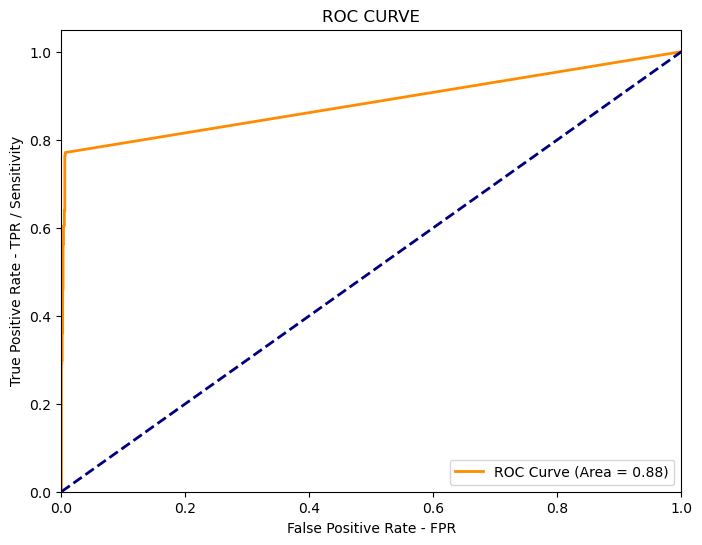

In [61]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(lstm_probs)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)

In [ ]:
print('N. apnee detected', len(apnea_events_time))
apnee_intervals = [event[:2] for event in apnea_events_time]

merged_intervals= [[check_stringa(t) for t in interval] for interval in merged_intervals]
apnee_intervals = [[check_stringa(t) for t in interval] for interval in apnee_intervals]


intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 46
N. Intervalli Intersecati/apnee trovate: 43
N. apnee non trovate: 10
N. apnee trovate in più: 3


### ML ensemble

In [63]:
X_test_ml = resp_feat_eval

rf_probs = rf.predict_proba(X_test_ml)[:, 1]
xgb_probs = xgb.predict_proba(X_test_ml)[:, 1]
lgr_probs = lgr.predict_proba(X_test_ml)[:, 1]
lda_probs = lda.predict_proba(X_test_ml)[:, 1]

Best threshold based on F1-score: 0.1644
Optimal threshold: 0.1644

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.98      0.92      0.95      1468
       Apnea       0.49      0.81      0.61       144

    accuracy                           0.91      1612
   macro avg       0.73      0.86      0.78      1612
weighted avg       0.94      0.91      0.92      1612


--- Confusion Matrix ---
[[1345  123]
 [  27  117]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9162
Negative Predictive Value (NPV): 0.9803
Sensitivity (Recall/TPR): 0.8125
Precision (PPV): 0.4875
Accuracy: 0.9069
F1 Score: 0.6094

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9128
Precision-Recall AUC Score: 0.4308


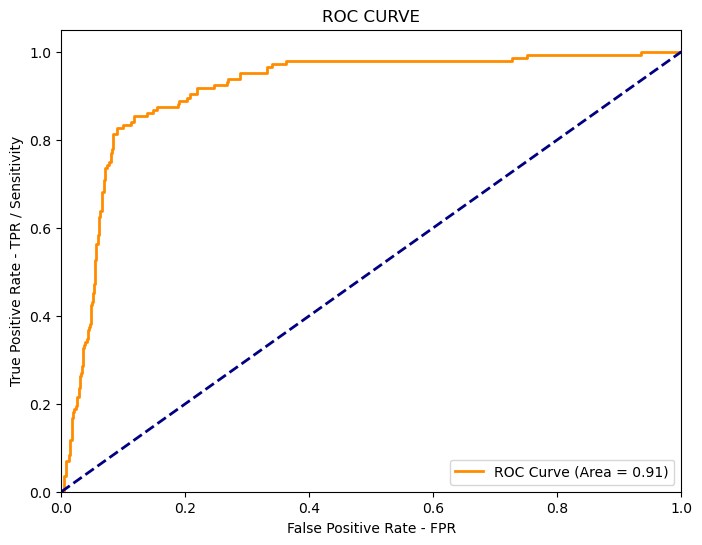

In [64]:
y_preds=clf.predict(X_test_ml)
y_proba = clf.predict_proba(X_test_ml)[:,1]

best_thresh = find_best_threshold(y_eval, y_proba, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_preds = (np.array(y_proba) >= best_thresh).astype(int)
metrics_dict = calculate_metrics(y_eval, y_preds, y_proba)

Apnea detected from segment 13 to 14, total duration: 70 seconds
Apnea detected from segment 65 to 66, total duration: 67 seconds
Apnea detected from segment 76 to 77, total duration: 74 seconds
Apnea detected from segment 109 to 111, total duration: 107 seconds
Apnea detected from segment 177 to 178, total duration: 79 seconds
Apnea detected from segment 265 to 266, total duration: 75 seconds
Apnea detected from segment 278 to 279, total duration: 69 seconds
Apnea detected from segment 302 to 305, total duration: 199 seconds
Apnea detected from segment 332 to 333, total duration: 75 seconds
Apnea detected from segment 341 to 342, total duration: 102 seconds
Apnea detected from segment 361 to 363, total duration: 119 seconds
Apnea detected from segment 375 to 378, total duration: 135 seconds
Apnea detected from segment 453 to 454, total duration: 83 seconds
Apnea detected from segment 476 to 477, total duration: 73 seconds
Apnea detected from segment 511 to 512, total duration: 67 seco

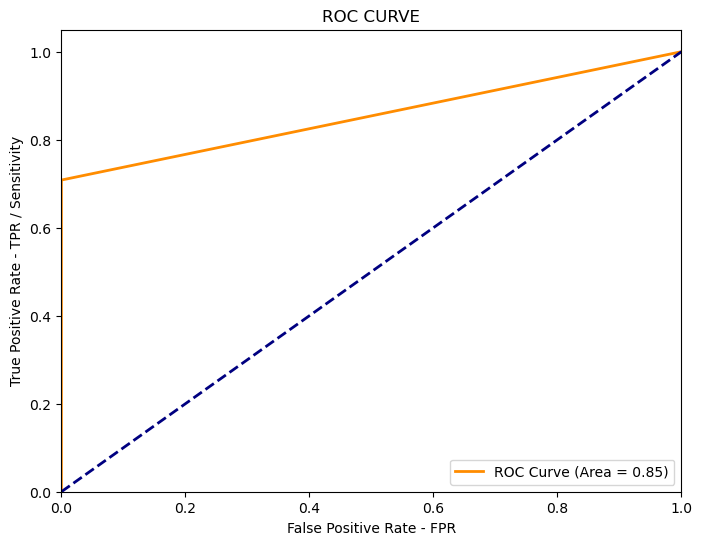

In [65]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(y_proba)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)

In [ ]:
print('N. apnee detected', len(apnea_events_time))

apnee_intervals = [event[:2] for event in apnea_events_time]

merged_intervals= [[check_stringa(t) for t in interval] for interval in merged_intervals]
apnee_intervals = [[check_stringa(t) for t in interval] for interval in apnee_intervals]

intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 41
N. Intervalli Intersecati/apnee trovate: 41
N. apnee non trovate: 12
N. apnee trovate in più: 0


### Hybrid Approach

In [67]:
print(f"rf_probs shape: {rf_probs.shape}")      # Output atteso: (11499, 1) o (11499,)
print(f"xgb_probs shape: {xgb_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lgr_probs shape: {lgr_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lda_probs shape: {lda_probs.shape}")    # Output atteso: (11499, 1) o (11499,)
print(f"lstm_probs shape: {lstm_probs.shape}")  # **Output problematico: (5000, 1) o (5000,)**

test_meta_features = np.column_stack((rf_probs, xgb_probs, lgr_probs, lda_probs, lstm_probs))
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
final_weighted_probs = np.average(test_meta_features, axis=1, weights=weights)

y_preds = (final_weighted_probs > 0.5).astype(int)

rf_probs shape: (1612,)
xgb_probs shape: (1612,)
lgr_probs shape: (1612,)
lda_probs shape: (1612,)
lstm_probs shape: (1612,)


Best threshold based on F1-score: 0.3287
Optimal threshold: 0.3287

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.98      0.91      0.95      1468
       Apnea       0.48      0.82      0.61       144

    accuracy                           0.91      1612
   macro avg       0.73      0.87      0.78      1612
weighted avg       0.94      0.91      0.92      1612


--- Confusion Matrix ---
[[1342  126]
 [  26  118]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.9142
Negative Predictive Value (NPV): 0.9810
Sensitivity (Recall/TPR): 0.8194
Precision (PPV): 0.4836
Accuracy: 0.9057
F1 Score: 0.6082

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.9300
Precision-Recall AUC Score: 0.4482


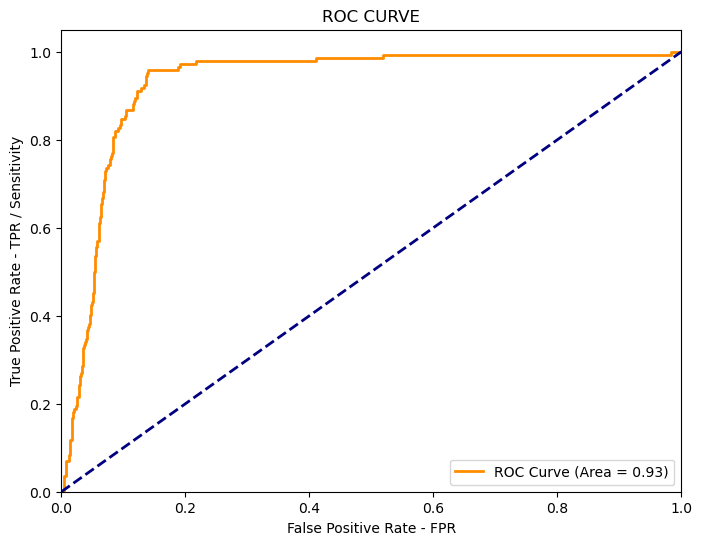

In [68]:
best_thresh = find_best_threshold(y_eval, final_weighted_probs, method='f1')
print(f"Optimal threshold: {best_thresh:.4f}")
y_preds = (np.array(final_weighted_probs) >= best_thresh).astype(int)
metrics_dict = calculate_metrics(y_eval, y_preds, final_weighted_probs)

Apnea detected from segment 13 to 14, total duration: 70 seconds
Apnea detected from segment 22 to 23, total duration: 70 seconds
Apnea detected from segment 65 to 66, total duration: 67 seconds
Apnea detected from segment 76 to 77, total duration: 74 seconds
Apnea detected from segment 109 to 111, total duration: 107 seconds
Apnea detected from segment 177 to 179, total duration: 116 seconds
Apnea detected from segment 265 to 266, total duration: 75 seconds
Apnea detected from segment 278 to 279, total duration: 69 seconds
Apnea detected from segment 302 to 305, total duration: 199 seconds
Apnea detected from segment 332 to 333, total duration: 75 seconds
Apnea detected from segment 341 to 342, total duration: 102 seconds
Apnea detected from segment 361 to 363, total duration: 119 seconds
Apnea detected from segment 375 to 378, total duration: 135 seconds
Apnea detected from segment 453 to 454, total duration: 83 seconds
Apnea detected from segment 476 to 477, total duration: 73 secon

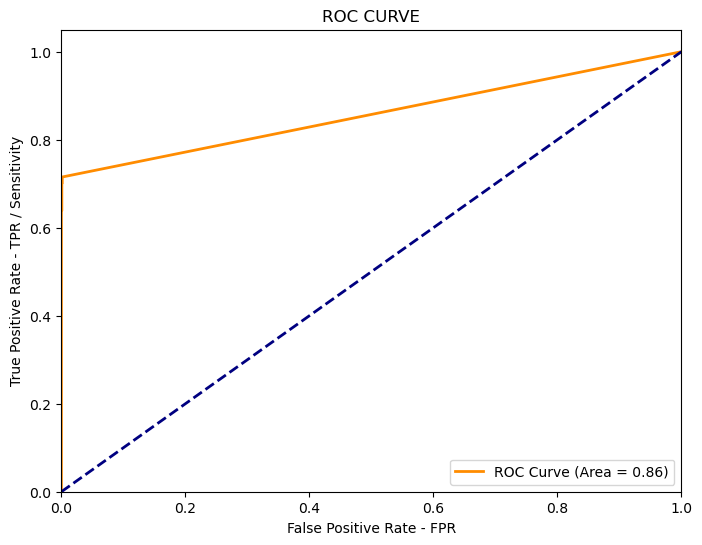

In [69]:
y_pred_apneas, apnea_events, apnea_events_time = check_apnea_criteria(X_eval, y_preds, time_data, resp_int, None)
# Print the detected apnea events
for start, end, duration in apnea_events:
    print(f"Apnea detected from segment {start} to {end}, total duration: {duration} seconds")

#apply the mask of the new apneas refined with the apnea criteria also to the probabilities 
y_pred_apneas_np = np.array(y_pred_apneas)
y_prob_np = np.array(final_weighted_probs)

mask = (y_pred_apneas_np == 0)
y_probs_check = y_prob_np
y_probs_check[mask] = 0

metrics_dict = calculate_metrics(y_eval, y_pred_apneas, y_probs_check)


In [70]:
print('N. apnee detected', len(apnea_events_time))

apnee_intervals = [event[:2] for event in apnea_events_time]

merged_intervals= [[check_stringa(t) for t in interval] for interval in merged_intervals]
apnee_intervals = [[check_stringa(t) for t in interval] for interval in apnee_intervals]

intersecting, unique_list1, unique_list2 = compare_intervals(merged_intervals, apnee_intervals)

print("N. Intervalli Intersecati/apnee trovate:", len(intersecting))
print("N. apnee non trovate:", len(unique_list1))
print("N. apnee trovate in più:", len(unique_list2))

N. apnee detected 42
N. Intervalli Intersecati/apnee trovate: 41
N. apnee non trovate: 12
N. apnee trovate in più: 1
